# Análisis del mercado eléctrico español

Análisis del precio diario del mercado eléctrico español (2014–2018), la demanda y la generación por tecnología.

In [1]:
# Librerías para manipulación, visualización y carga portable de datos.
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Usamos una ruta para Kaggle y otra para ejecución local en VS Code.
kaggle_path = '/kaggle/input/datasets/manualrg/spanish-electricity-market-demand-gen-price/spain_energy_market.csv'
local_path = 'spain_energy_market.csv'

# Cargamos el dataset desde la ruta que exista en el entorno actual.
if os.path.exists(kaggle_path):
    df_energia = pd.read_csv(kaggle_path)
    print("Cargado desde el entorno de Kaggle")
elif os.path.exists(local_path):
    df_energia = pd.read_csv(local_path)
    print("Cargado desde el entorno local (VS Code)")
else:
    raise FileNotFoundError("No se encontro el archivo 'spain_energy_market.csv' en ninguna de las rutas.")

# Vista inicial: permite comprobar que las columnas se cargaron correctamente.
df_energia.head()

Cargado desde el entorno de Kaggle


,datetime,id,name,geoid,geoname,value
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500


## Exploración inicial

Verificamos estructura, tipos de datos, faltantes e indicadores disponibles antes de transformar el dataset.

In [2]:
# Revisamos dimensiones, tipos de datos y valores no nulos por columna.
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  40212 non-null  object 
 1   id        40212 non-null  int64  
 2   name      34734 non-null  object 
 3   geoid     10956 non-null  float64
 4   geoname   10956 non-null  object 
 5   value     40212 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.8+ MB


In [3]:
# Resumen estadístico inicial de la variable numérica disponible.
df_energia.describe()

,id,geoid,value
count,40212.000000,10956.000000,4.021200e+04
mean,2767.757286,2.000000,1.325967e+05
std,4014.664966,0.816534,2.147129e+05
min,3.000000,1.000000,-1.426133e+06
25%,600.000000,1.000000,5.112708e+01
50%,602.000000,2.000000,2.778778e+04
75%,1334.000000,3.000000,1.615399e+05
max,10258.000000,3.000000,2.584390e+06


In [4]:
# Identificamos valores faltantes antes de seleccionar los indicadores de interés.
df_energia.isnull().sum()

datetime        0
id              0
name         5478
geoid       29256
geoname     29256
value           0
dtype: int64

In [5]:
# Cada id representa un indicador del mercado eléctrico; contamos sus registros.
df_energia['id'].value_counts()

id
600      10956
602       1826
1334      1826
17        1826
14        1826
10064     1826
10073     1825
10258     1825
10141     1825
1293      1825
4         1825
3         1824
10167     1823
9         1793
1119      1664
1117      1619
1120      1566
1118       712
Name: count, dtype: int64

In [6]:
# Revisamos los nombres de los indicadores para elegir las series a analizar.
df_energia['name'].value_counts()

name
Precio mercado SPOT Diario ESP                                            1826
Precio mercado SPOT Diario FRA                                            1826
Precio mercado SPOT Diario POR                                            1826
Energía asignada en Mercado SPOT Diario España                            1826
Energía asignada en Mercado SPOT Diario Francia                           1826
Generación programada PBF Gas Natural Cogeneración                        1826
Generación programada PBF Solar fotovoltaica                              1826
Generación programada PBF UGH + no UGH                                    1826
Generación programada PBF Eólica                                          1825
Generación programada PBF total                                           1825
Demanda programada PBF total                                              1825
Demanda real                                                              1825
Generación programada PBF Nuclear              

In [7]:
# Investigamos los ids asociados a nombres nulos antes de descartarlos mediante el filtrado.
df_energia[df_energia['name'].isnull()]['id'].value_counts()

id
600    5478
Name: count, dtype: int64

## Limpieza y preprocesamiento

Seleccionamos precio, demanda y generación; convertimos la fecha y pivotamos a formato ancho, con una fila por día.

In [8]:
# Filtramos solo los indicadores que nos interesan
indicadores_interes = [
    'Precio mercado SPOT Diario ESP',
    'Demanda real',
    'Generación programada PBF Eólica',
    'Generación programada PBF Solar fotovoltaica',
    'Generación programada PBF Nuclear'
]

df_filtrado = df_energia[df_energia['name'].isin(indicadores_interes)].copy()

# Para el precio, nos aseguramos de quedarnos solo con España (por si hay duplicados de FRA/POR con mismo name)
df_filtrado = df_filtrado[
    (df_filtrado['name'] != 'Precio mercado SPOT Diario ESP') | 
    (df_filtrado['geoname'] == 'España')
]

df_filtrado['name'].value_counts()

name
Precio mercado SPOT Diario ESP                  1826
Generación programada PBF Solar fotovoltaica    1826
Demanda real                                    1825
Generación programada PBF Eólica                1825
Generación programada PBF Nuclear               1825
Name: count, dtype: int64

In [9]:
# Convertimos datetime a fecha para ordenar y agrupar correctamente la serie temporal.
df_filtrado['datetime'] = pd.to_datetime(df_filtrado['datetime'])
df_filtrado.dtypes

datetime    datetime64[ns]
id                   int64
name                object
geoid              float64
geoname             object
value              float64
dtype: object

In [10]:
# Pasamos de formato largo a formato ancho: una fila por fecha y una columna por indicador.
df_energia_wide = df_filtrado.pivot_table(
    index='datetime',
    columns='name',
    values='value',
    aggfunc='mean'  # por si hay algún duplicado de datetime+name
)

df_energia_wide.head()

name,Demanda real,Generación programada PBF Eólica,Generación programada PBF Nuclear,Generación programada PBF Solar fotovoltaica,Precio mercado SPOT Diario ESP
datetime,,,,,
2014-01-01 23:00:00,28191.597222,277443.9,144654.6,7027.3,25.280833
2014-01-02 23:00:00,28465.180556,237323.1,146177.8,12817.8,39.924167
2014-01-03 23:00:00,26860.493056,329506.6,145055.3,12532.5,4.992083
2014-01-04 23:00:00,25333.597222,292138.3,145200.2,14108.3,4.091667
2014-01-05 23:00:00,23905.541667,223942.0,135624.0,14555.6,13.587500


In [11]:
# Verificamos la estructura resultante después de pivotar las series.
df_energia_wide.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2014-01-01 23:00:00 to 2018-12-31 23:00:00
Data columns (total 5 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Demanda real                                  1825 non-null   float64
 1   Generación programada PBF Eólica              1825 non-null   float64
 2   Generación programada PBF Nuclear             1825 non-null   float64
 3   Generación programada PBF Solar fotovoltaica  1826 non-null   float64
 4   Precio mercado SPOT Diario ESP                1826 non-null   float64
dtypes: float64(5)
memory usage: 85.6 KB


In [12]:
# Medimos los huecos temporales que aparecen cuando una serie no tiene dato en una fecha.
df_energia_wide.isnull().sum()

name
Demanda real                                    1
Generación programada PBF Eólica                1
Generación programada PBF Nuclear               1
Generación programada PBF Solar fotovoltaica    0
Precio mercado SPOT Diario ESP                  0
dtype: int64

In [13]:
df_energia_wide = df_energia_wide.sort_index()  # por las dudas, aseguramos orden cronológico
# La interpolación lineal estima huecos internos entre fechas vecinas.
# Mantiene las series alineadas sin eliminar días; no sustituye datos reales.
df_energia_wide = df_energia_wide.interpolate(method='linear')

df_energia_wide.isnull().sum()  # debería dar todo 0

name
Demanda real                                    0
Generación programada PBF Eólica                0
Generación programada PBF Nuclear               0
Generación programada PBF Solar fotovoltaica    0
Precio mercado SPOT Diario ESP                  0
dtype: int64

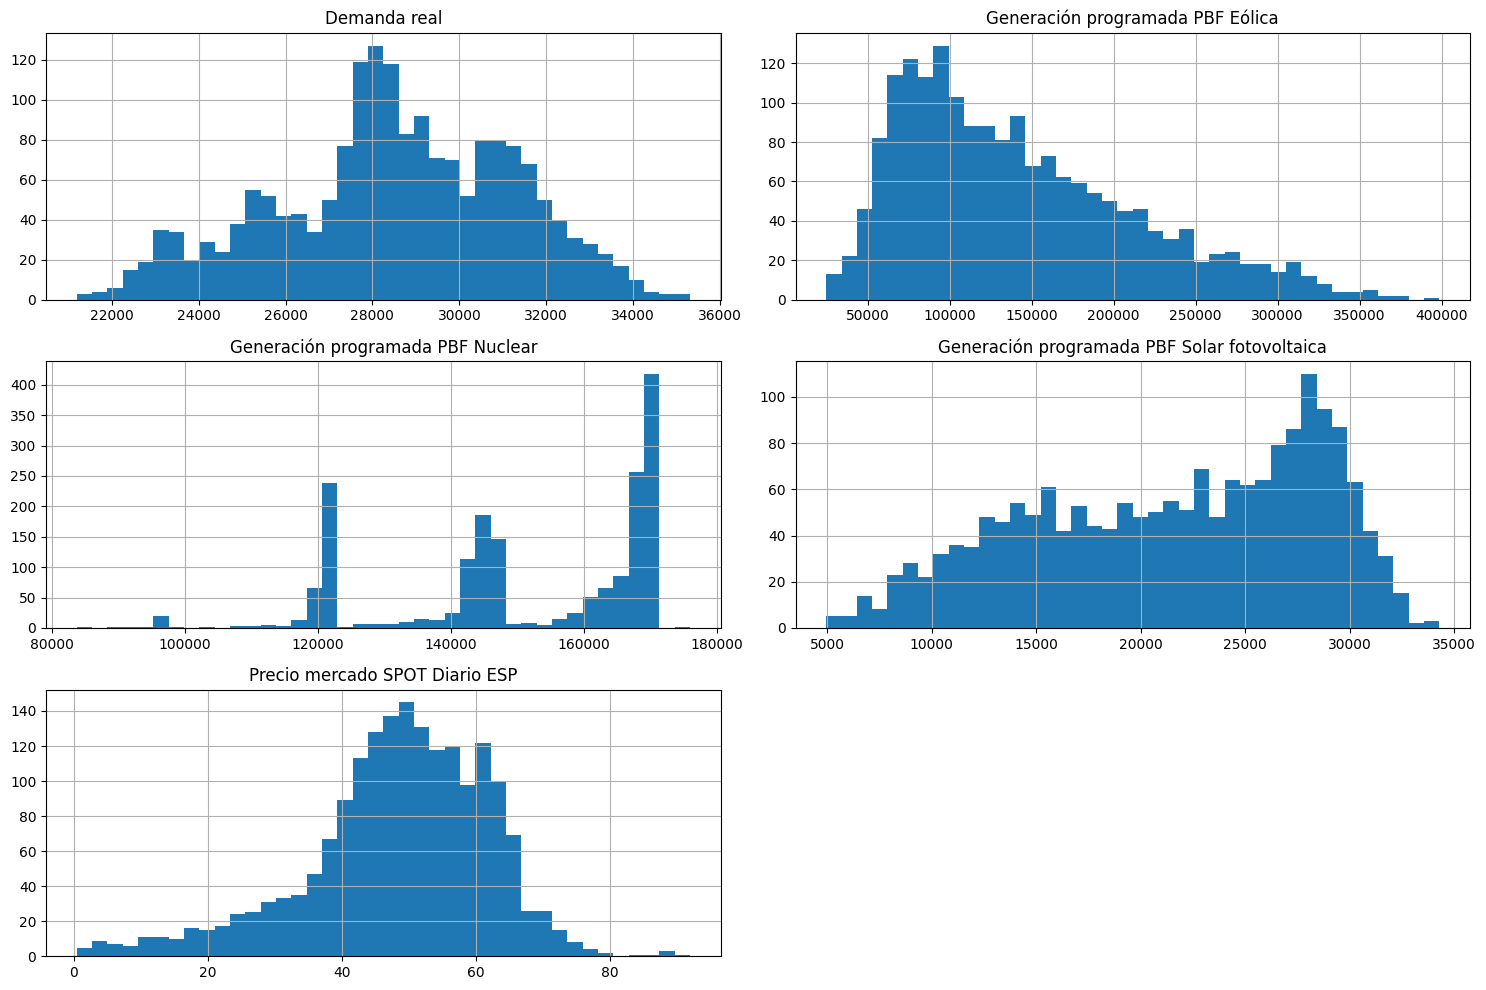

In [14]:
# Visualizamos la distribución de cada indicador y posibles valores extremos.
df_energia_wide.hist(bins=40, figsize=(15, 10))
plt.tight_layout()
plt.show()

## Análisis simple: distribuciones, calendario y tendencia

Estudiamos la distribución de los indicadores, el precio por día de semana y la evolución diaria y mensual.

In [15]:
df_energia_wide['año'] = df_energia_wide.index.year
df_energia_wide['mes'] = df_energia_wide.index.month
df_energia_wide['dia_semana'] = df_energia_wide.index.day_name()
df_energia_wide['estacion'] = df_energia_wide.index.month % 12 // 3 + 1  # 1=invierno,2=primavera,3=verano,4=otoño

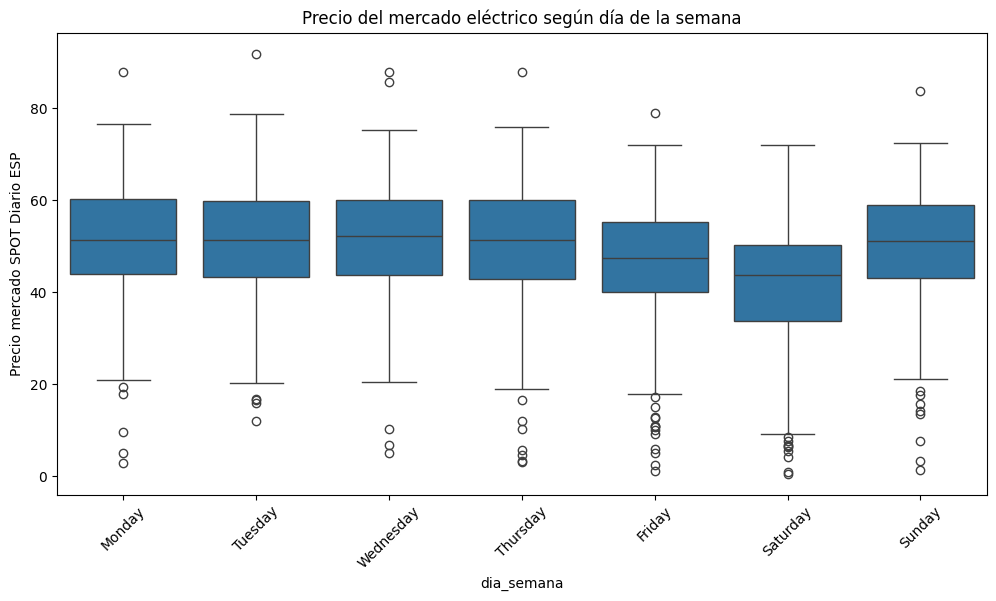

In [16]:
# Comparamos la distribución del precio para cada día de la semana.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_energia_wide, x='dia_semana', y='Precio mercado SPOT Diario ESP',
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Precio del mercado eléctrico según día de la semana')
plt.xticks(rotation=45)
plt.show()

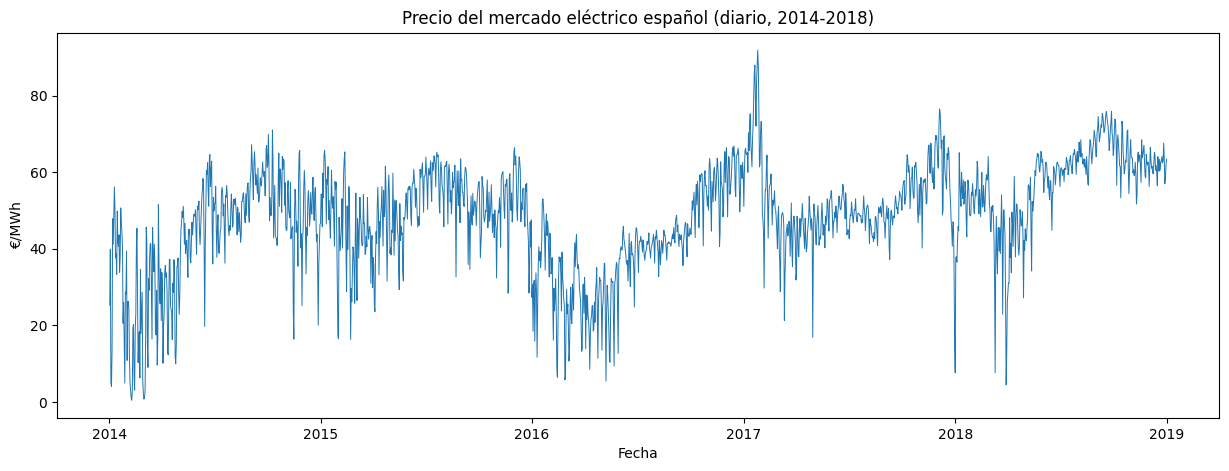

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(df_energia_wide.index, df_energia_wide['Precio mercado SPOT Diario ESP'], linewidth=0.7)
plt.title('Precio del mercado eléctrico español (diario, 2014-2018)')
plt.xlabel('Fecha')
plt.ylabel('€/MWh')
plt.show()

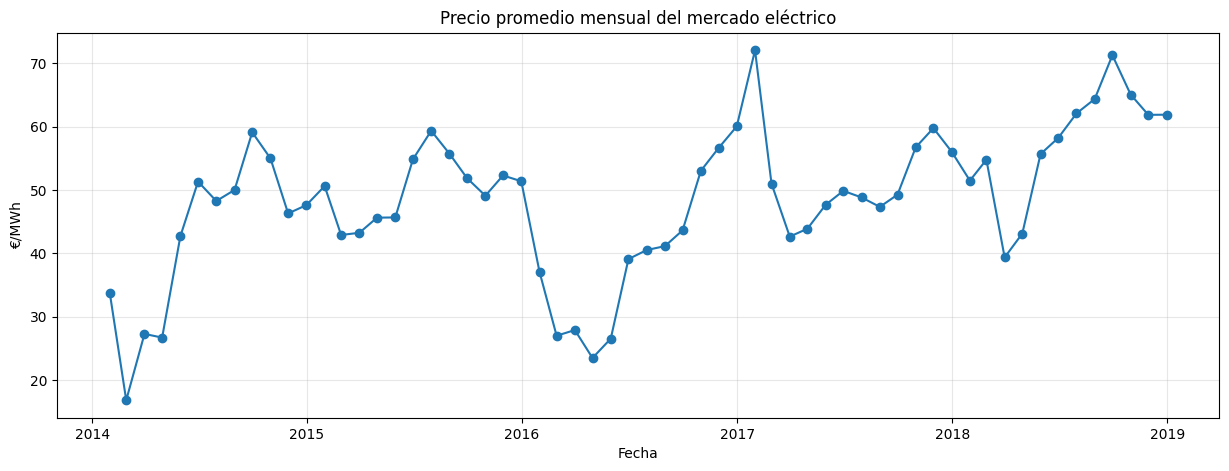

In [18]:
# Agregamos por mes para suavizar la variación diaria y observar tendencias.
precio_mensual = df_energia_wide['Precio mercado SPOT Diario ESP'].resample('ME').mean()

plt.figure(figsize=(15, 5))
plt.plot(precio_mensual.index, precio_mensual.values, marker='o', linewidth=1.5)
plt.title('Precio promedio mensual del mercado eléctrico')
plt.xlabel('Fecha')
plt.ylabel('€/MWh')
plt.grid(alpha=0.3)
plt.show()

## Análisis complejo: precio, demanda y generación

Comparamos el precio con la generación eólica y usamos correlaciones y pairplots para identificar asociaciones. Estas relaciones no demuestran causalidad.

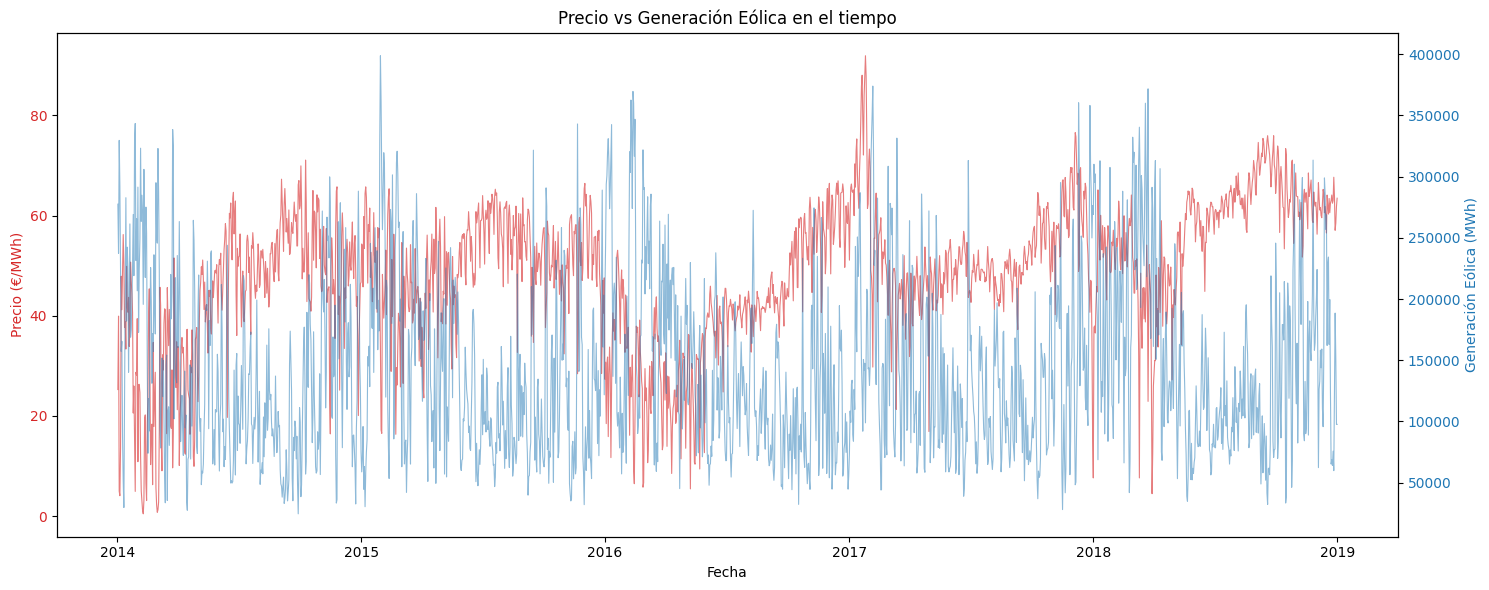

In [19]:
# Comparamos la evolución temporal del precio con la generación eólica.
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df_energia_wide.index, df_energia_wide['Precio mercado SPOT Diario ESP'], 
         color='tab:red', alpha=0.6, linewidth=0.8, label='Precio (€/MWh)')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(df_energia_wide.index, df_energia_wide['Generación programada PBF Eólica'], 
         color='tab:blue', alpha=0.5, linewidth=0.8, label='Generación Eólica')
ax2.set_ylabel('Generación Eólica (MWh)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Precio vs Generación Eólica en el tiempo')
fig.tight_layout()
plt.show()

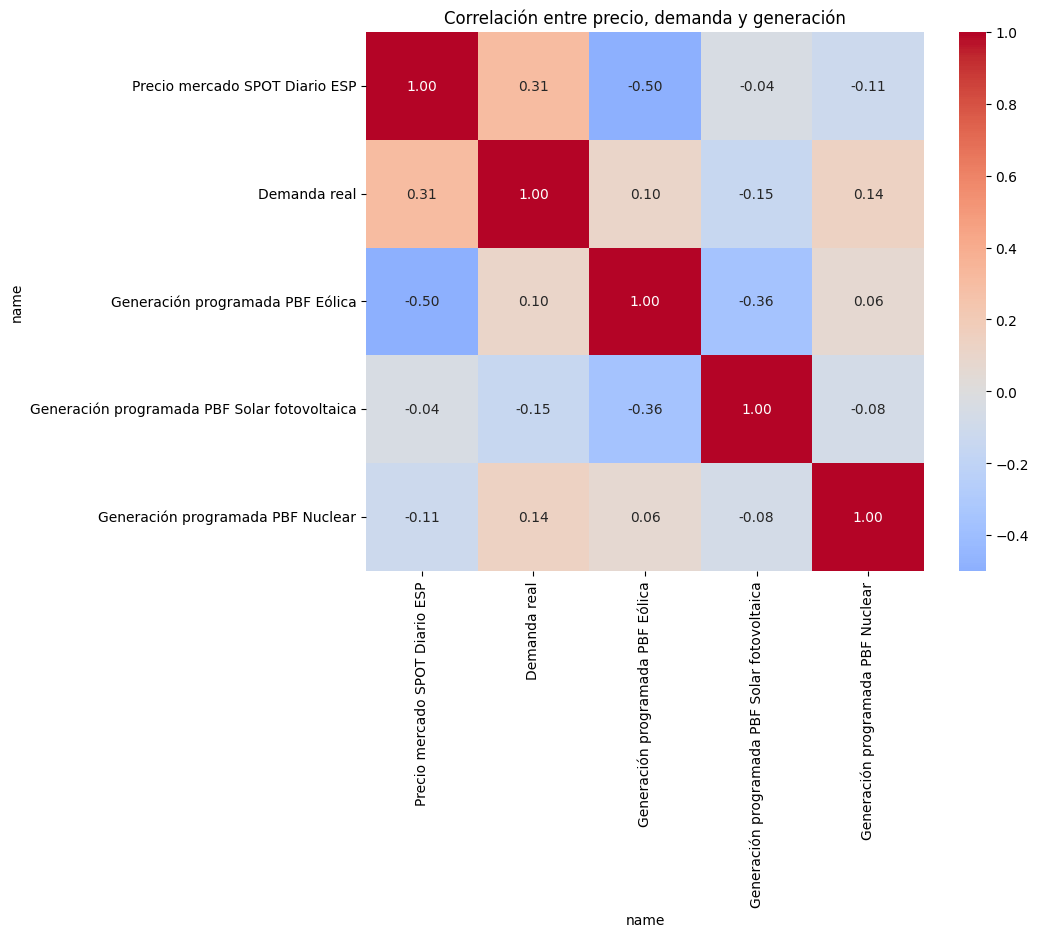

In [20]:
# Calculamos correlaciones lineales entre las principales series del análisis.
cols_indicadores = ['Precio mercado SPOT Diario ESP', 'Demanda real', 
                     'Generación programada PBF Eólica', 
                     'Generación programada PBF Solar fotovoltaica',
                     'Generación programada PBF Nuclear']

corr_energia = df_energia_wide[cols_indicadores].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_energia, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre precio, demanda y generación')
plt.show()

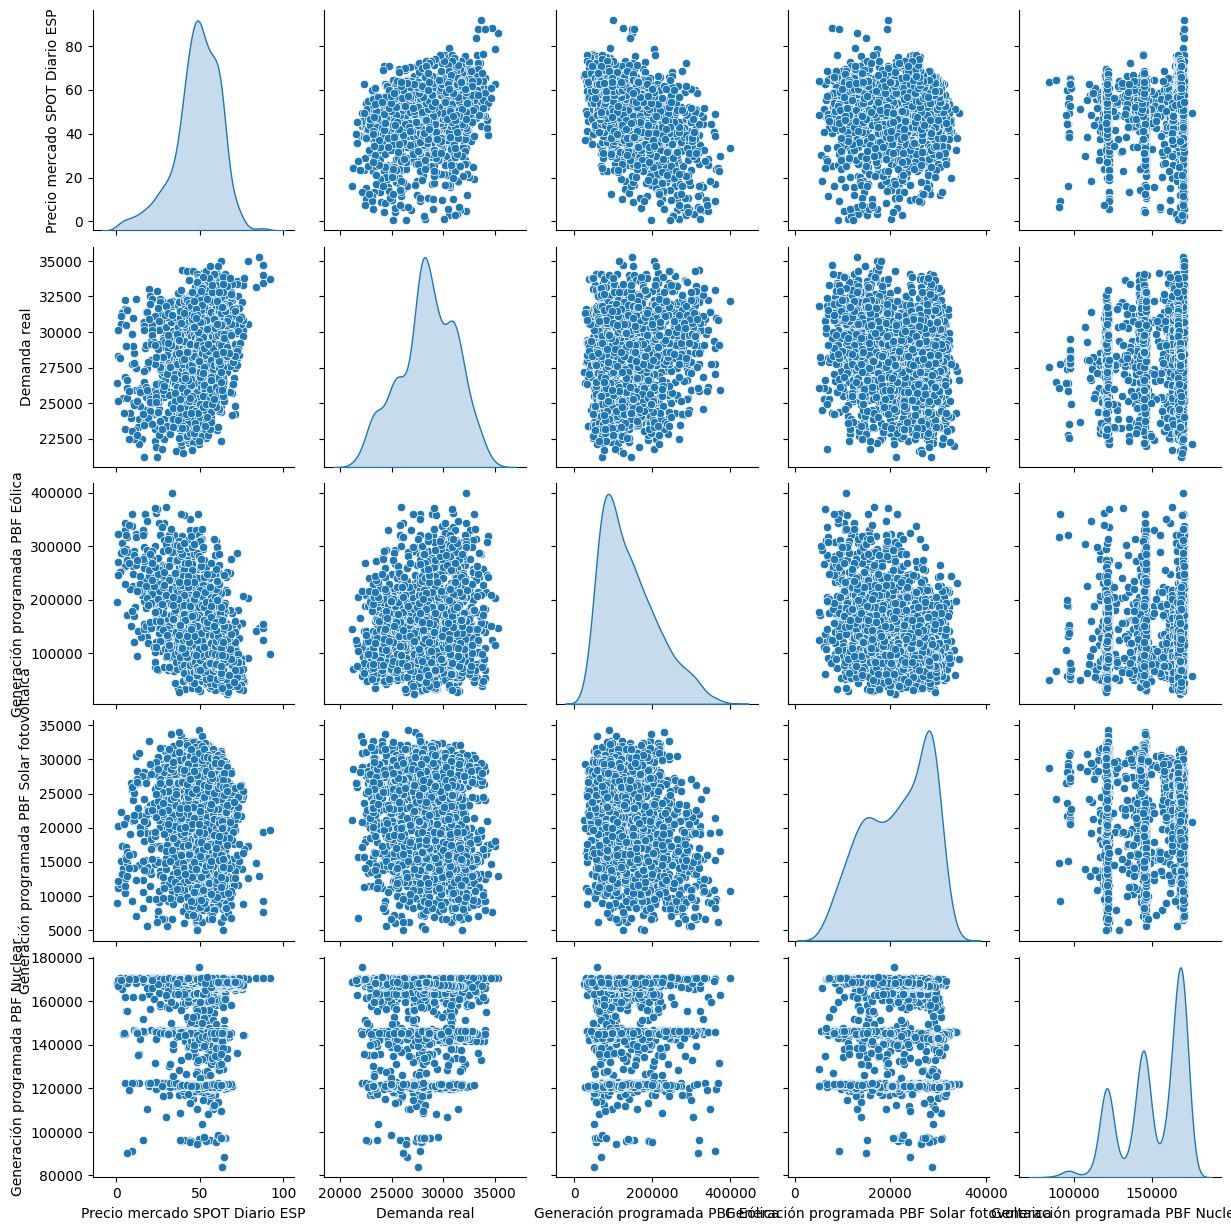

In [21]:
# El pairplot muestra relaciones, dispersión y distribuciones entre los indicadores.
sns.pairplot(df_energia_wide[cols_indicadores], diag_kind='kde')
plt.show()

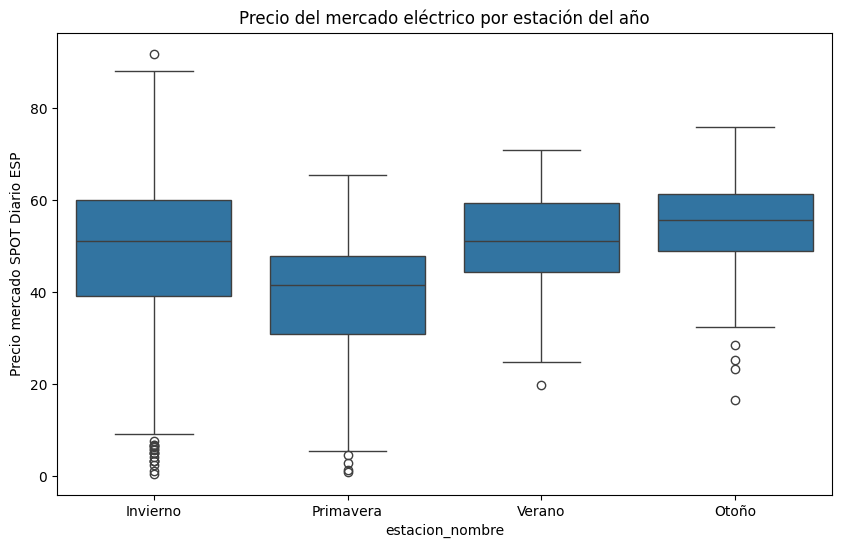

In [22]:
# Traducimos el código de estación a texto para una visualización más clara.
mapa_estaciones = {1: 'Invierno', 2: 'Primavera', 3: 'Verano', 4: 'Otoño'}
df_energia_wide['estacion_nombre'] = df_energia_wide['estacion'].map(mapa_estaciones)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_energia_wide, x='estacion_nombre', y='Precio mercado SPOT Diario ESP',
            order=['Invierno', 'Primavera', 'Verano', 'Otoño'])
plt.title('Precio del mercado eléctrico por estación del año')
plt.show()

## Interpretación de los gráficos

**Precio por día.** El sábado presenta la mediana más baja (aprox. 43.8 €/MWh), mientras que miércoles, jueves y lunes se sitúan cerca de 51–52 €/MWh. El patrón es compatible con una menor actividad de fin de semana.

**Tendencia temporal.** La serie diaria es volátil. El promedio mensual permite distinguir sus movimientos de corto plazo: el mínimo aparece en febrero de 2014 (aprox. 16.8 €/MWh) y el máximo en enero de 2017 (aprox. 72.1 €/MWh).

**Precio, demanda y eólica.** La generación eólica se asocia negativamente de forma moderada con el precio (correlación aprox. -0.50), mientras que la demanda se asocia positivamente de forma moderada (aprox. 0.31). Son asociaciones, no evidencia de causalidad.

**Precio por estación.** Otoño presenta la mediana más alta (aprox. 55.7 €/MWh) y primavera la más baja (aprox. 41.4 €/MWh).

## Conclusiones

- El precio eléctrico presenta variación semanal, estacional y mensual.
- Los sábados registran precios típicos más bajos que varios días laborables.
- Eólica y demanda se asocian al precio en direcciones opuestas; es necesario un análisis causal para atribuir efectos.